Corrective Retrieval-Augmented Generation (CRAG) is a RAG architecture that adds a correction and validation layer to standard RAG pipelines.

How CRAG works — Step by Step

User query arrives
Example: “Best practices for MongoDB indexing”

Initial retrieval
Hybrid retrieval (dense + sparse vectors)
Optional reranker (cross-encoder)

Validation (core of CRAG) -> CORRECTIVE RAG
LLM or a classifier checks:
Are retrieved documents relevant?
Are they complete?
Are they trustworthy?

Output:
Accept document
Discard document
Flag for correction / re-retrieval
Correction / Re-retrieval

If validation fails, CRAG can:
Rewrite or expand the query
Retrieve again from vector DB
Query external sources (web search, API)

Final retrieval → LLM

Only validated and corrected documents are sent to the LLM for answer generation.
This reduces hallucinations and improves accuracy.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY']=os.getenv('LANGSMITH_API_KEY')
os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_PROJECT']='Agent_React'


In [3]:
import nest_asyncio
nest_asyncio.apply()

In [4]:
from langchain_community.document_loaders import PlaywrightURLLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [5]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [6]:
async def load_docs(urls):
    """
    Load multiple web pages asynchronously using PlaywrightURLLoader.

    Args:
        urls (list): List of URLs to load.

    Returns:
        list: List of Langchain Document objects.
    """
    loader = PlaywrightURLLoader(urls=urls)
    docs =await loader.aload()
    return docs

    

In [7]:
docs =await load_docs(urls)
print(len(docs))
print(docs[0].page_content)

3
LLM Powered Autonomous Agents

Date: June 23, 2023 | Estimated Reading Time: 31 min | Author: Lilian Weng

Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.

Agent System Overview#

In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:

Planning

Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.

Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.

Memory

Short-term memory: I would conside

In [8]:
splitter =RecursiveCharacterTextSplitter(chunk_size=800,
chunk_overlap =120)

doc_splits =splitter.split_documents(docs)

print(len(doc_splits))
print(doc_splits[0].page_content[:500])

179
LLM Powered Autonomous Agents

Date: June 23, 2023 | Estimated Reading Time: 31 min | Author: Lilian Weng

Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.

Agent System Overview#

In a LLM-powered 


In [9]:
# add to any vector store

vector_store =FAISS.from_documents(documents=doc_splits,
embedding=OpenAIEmbeddings())

retriever = vector_store.as_retriever()

In [10]:
retriever.invoke("what is longterm memory")

[Document(id='34919b97-bbd4-4d77-b853-65c170560d5d', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Short-Term Memory (STM) or Working Memory: It stores information that we are currently aware of and needed to carry out complex cognitive tasks such as learning and reasoning. Short-term memory is believed to have the capacity of about 7 items (Miller 1956) and lasts for 20-30 seconds.\n\nLong-Term Memory (LTM): Long-term memory can store information for a remarkably long time, ranging from a few days to decades, with an essentially unlimited storage capacity. There are two subtypes of LTM:\n\nExplicit / declarative memory: This is memory of facts and events, and refers to those memories that can be consciously recalled, including episodic memory (events and experiences) and semantic memory (facts and concepts).'),
 Document(id='2c4b41b1-501a-40df-b608-21efaf6e09e7', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, p

In [11]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi". The assistant should respond politely. There\'s no special instruction beyond normal. So greet back and ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 72, 'total_tokens': 120, 'completion_time': 0.099139574, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.002638918, 'prompt_tokens_details': None, 'queue_time': 0.004499135, 'total_time': 0.101778492}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_854fa9be4c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb548-1b8a-7b43-9efc-62d8f97932f6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 48, 'total_tokens': 120, 'output_token_details': {'reasoning': 30}})

In [12]:
from pydantic import BaseModel,Field
from typing import TypedDict,Literal
from langchain_core.prompts import ChatPromptTemplate

In [13]:
class grade_documents(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score : str =Field(description="Documents are relevant to the question, 'yes' or 'no'")

structured_llm_grader =llm.with_structured_output(grade_documents)

system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""




prompt =ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Retreived documents:\n\n {document} user question:\n\n {question}")
    ]
)

retrieval_grader = prompt|structured_llm_grader

#check whether working or not
question ="agent memory"
docs =retriever.invoke(question)
docs_text =docs[0].page_content
grade = retrieval_grader.invoke({"question": question, "document": docs_text})
print(grade)




binary_score='yes'


In [14]:
# #check
# c=0
# for doc in docs:
#     doc_txt = doc.page_content
#     grade = retrieval_grader.invoke({"question": question, "document": doc_txt})
#     print(doc_txt[:100], grade)  # preview + relevance score
#     print(grade)
#     c+=1
# print(c)


In [15]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
client =Client()
rag_prompt = client.pull_prompt("rlm/rag-prompt")

In [16]:
# Chain
rag_chain = rag_prompt | llm | StrOutputParser() #StrOutputParser() is a LangChain utility that takes the raw string output from an LLM and converts it into a cleaner, structured format. StrOutputParser() is the simplest parser — it takes whatever the LLM returns and gives it back as a string without extra metadata or tokens.

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Agent memory consists of two layers: short‑term memory, which is the model’s in‑context context used for immediate reasoning, and long‑term memory, an external store (often a vector database) that records the agent’s experiences as natural‑language observations. A retrieval model selects relevant memories based on recency, importance, and relevance, and a reflection mechanism can synthesize these into higher‑level summaries to guide future behavior. This combination lets agents retain and recall information over extended periods while still reacting to recent events.


In [17]:
# question rewriter
# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

prompt =ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human",
        f"here is the initial question \n\n {question}\n\n formulate an improved question")
    ]
)

rewriter_chain =prompt|llm|StrOutputParser()

rewriter_chain.invoke({"question":question})

'**Improved search‑optimized question:**  \n*What is “agent memory” in artificial intelligence, and what methods are used to implement and manage memory so that AI agents can retain and recall information?*'

In [18]:
# web search tool
from langchain_community.tools import TavilySearchResults

web_search_tool =TavilySearchResults(k=3)

C:\Users\Mohamed Arshad\AppData\Local\Temp\ipykernel_33444\1510709736.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool =TavilySearchResults(k=3)


In [19]:
from typing import List

In [20]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question:str
    generation:str
    web_search:str
    documents:List[str]

In [21]:
def retrieve(state:GraphState):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state['question']
    documents =retriever.invoke(question)

    return {"documents":documents,"question":question}

In [22]:
def generate(state:GraphState):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [23]:
def grade_documents(state:GraphState):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")

    class grade_documents(BaseModel):
        """Binary score for relevance check on retrieved documents."""
        binary_score : str =Field(description="Documents are relevant to the question, 'yes' or 'no'")

    structured_llm_grader =llm.with_structured_output(grade_documents)

    system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

    prompt =ChatPromptTemplate.from_messages(
        [
            ("system",system),
            ("human","Retreived documents:\n\n {documents} user question:\n\n {question}")
        ]
    )

    retrieval_grader = prompt|structured_llm_grader

    filtered_docs=[]
    web_search ="No"

    documents =state['documents']
    question=state['question']

    for d in documents:
        score= retrieval_grader.invoke({"question":question,"documents":d.page_content})
        grade = score.binary_score

        if grade == 'yes':
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT IRRELEVANT---")
            web_search="yes"
            continue
    
    return {"documents":filtered_docs,"question":question,"web_search":web_search}
            
        


    

In [24]:
def transform_query(state:GraphState):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    # question rewriter
    # Prompt
    system = """You a question re-writer that converts an input question to a better version that is optimized \n 
        for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

    prompt =ChatPromptTemplate.from_messages(
        [
            ("system",system),
            ("human",
            f"here is the initial question \n\n {question}\n\n formulate an improved question")
        ]
    )

    rewriter_chain =prompt|llm|StrOutputParser()

    # question rewriter
    better_question =rewriter_chain.invoke({"question":question})

    return {"documents":documents,"question":better_question}



In [25]:
from langchain_core.documents import Document

In [26]:
def web_search(state:GraphState):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    docs =web_search_tool.invoke({"query":question})
    web_results ="\n\n".join([d['content'] for d in docs])
    web_results =Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

In [27]:
def decide_to_generate(state:GraphState):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    web_search=state['web_search']

    if web_search=="yes":
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return 'transform_query'
    else:
        print("---DECISION: GENERATE---")
        return 'generate'


In [28]:
from langgraph.graph import StateGraph,START,END

workflow =StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

workflow.add_edge(START,"retrieve")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges("grade_documents",decide_to_generate,
{
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

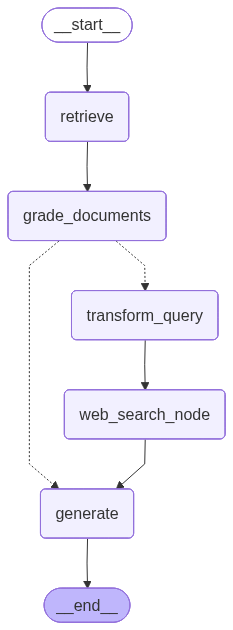

In [29]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [30]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT IRRELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': '**Improved search‑optimized question:**  \n*What are the different types of memory used by intelligent (AI) agents?*',
 'generation': 'Intelligent AI agents rely on **short‑term (working) memory** to hold the immediate context of a task or conversation, and **long‑term memory** for persistent knowledge across sessions.  Long‑term memory is commonly broken into **episodic memory** (specific past events), **semantic memory** (general facts and concepts), and **procedural memory** (rules or “how‑to” procedures), with further specialized forms such as conversation, persona, toolbox, entity, and workflow memory built on these foundations.',
 'web_search': 'yes',
 'documents': [Document(id='09449be6-f5c7-43bb-aed8-9198377a09df', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby im

In [31]:
app.invoke({"question":"What is long term memory in agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT IRRELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': '**Improved question:**  \n*What is meant by “long‑term memory” in the context of an AI agent’s memory system, and how is it implemented or used compared to short‑term memory?*',
 'generation': 'In an AI agent, “long‑term memory” refers to an external, persistent store that lets the agent keep and later retrieve information across sessions—often as embeddings in a vector database or other durable storage—so it can recall past experiences, facts, or user details indefinitely. By contrast, short‑term memory is limited to the model’s current context window or a rolling buffer that holds only the most recent dialogue or observations for immediate reasoning. The agent writes important events to the long‑term store and queries it (e.g., via semantic similarity) when needed, while using short‑term memory for the immediate turn‑by‑turn flow.',
 'web_search': 'yes',
 'documents': [Document(id='09449be6-f5c7-43bb-aed8-9198377a09df', metadata={'source': 'https://lilianweng.github.io/